In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

candidate_output_dirs = [
    Path.cwd() / "outputs",
    Path.cwd() / "Preprocessing" / "outputs",
    Path.cwd().parent / "Preprocessing" / "outputs",
    Path.cwd().parent / "outputs",
]

OUTPUT_DIR = None
for candidate in candidate_output_dirs:
    if (candidate / "audi_q4_lifecycle_clean.parquet").exists():
        OUTPUT_DIR = candidate.resolve()
        break

if OUTPUT_DIR is None:
    checked = "\n".join(str(path.resolve()) for path in candidate_output_dirs)
    raise FileNotFoundError(f"Could not find lifecycle parquet. Checked:\n{checked}")

df = pd.read_parquet(OUTPUT_DIR / "audi_q4_lifecycle_clean.parquet")
sns.set_theme(style="whitegrid")
print(f"Loaded lifecycle parquet from: {OUTPUT_DIR}")

In [3]:
df.shape
df["status"].value_counts(normalize=True)
df["variant"].value_counts(dropna=False)
df[["price_eur", "mileage_km", "vehicle_age_months", "electric_range_km"]].describe()

,price_eur,mileage_km,vehicle_age_months,electric_range_km
count,2517.0,2514.0,2447.000000,2441.0
mean,38742.731426,33251.738663,28.198202,459.534207
std,9797.55848,28444.335341,15.032003,67.272273
min,16490.0,0.0,0.000000,100.0
25%,30480.0,8100.0,10.000000,412.0
50%,37500.0,26934.5,36.000000,466.0
75%,45480.0,51641.25,39.000000,513.0
max,99999.0,198108.0,59.000000,579.0


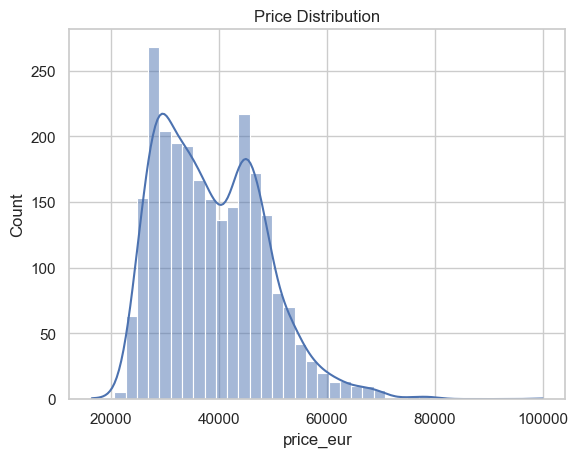

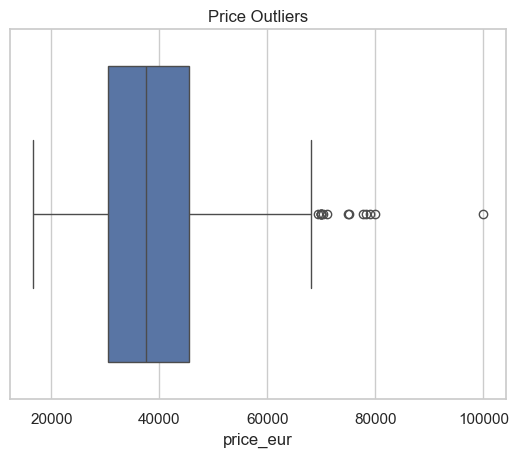

In [4]:
sns.histplot(df["price_eur"], bins=40, kde=True)
plt.title("Price Distribution")
plt.show()

sns.boxplot(x=df["price_eur"])
plt.title("Price Outliers")
plt.show()

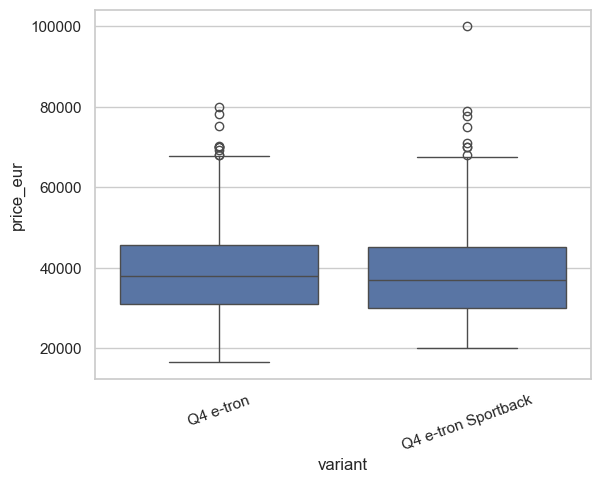

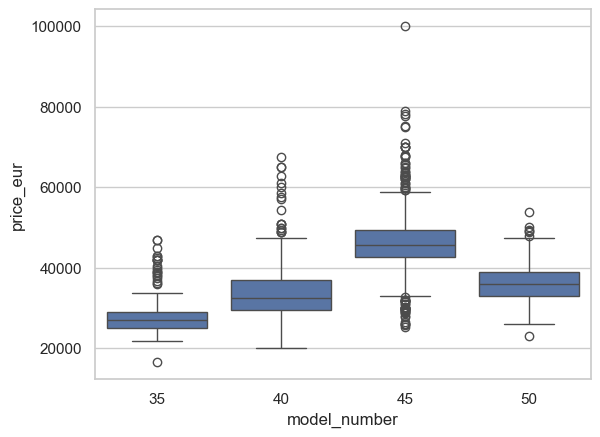

In [6]:
df.groupby("variant")["price_eur"].describe()

sns.boxplot(data=df, x="variant", y="price_eur")
plt.xticks(rotation=20)
plt.show()

sns.boxplot(data=df, x="model_number", y="price_eur", order=["35", "40", "45", "50"])
plt.show()

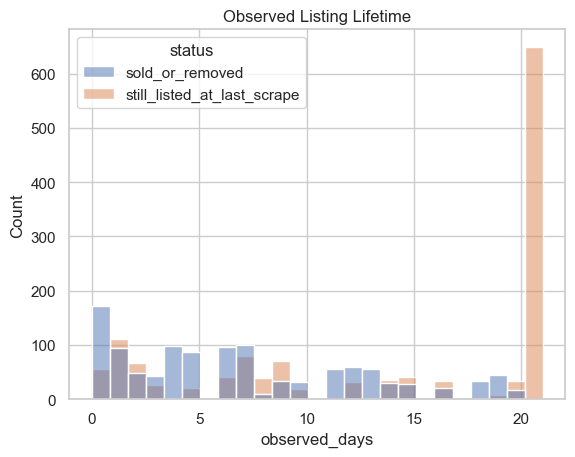

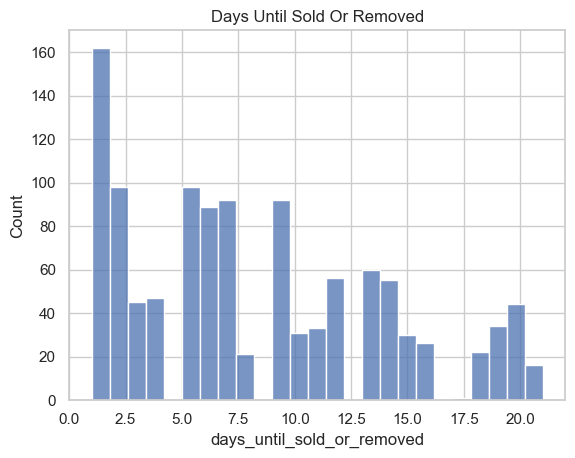

In [7]:
df.groupby("status")[["price_eur", "mileage_km", "observed_days"]].median()

sns.histplot(data=df, x="observed_days", hue="status", bins=25)
plt.title("Observed Listing Lifetime")
plt.show()

sold = df[df["sold_flag"]]

sns.histplot(sold["days_until_sold_or_removed"], bins=25)
plt.title("Days Until Sold Or Removed")
plt.show()

In [8]:
df["price_band"] = pd.qcut(df["price_eur"], q=5, duplicates="drop")
df["mileage_band"] = pd.qcut(df["mileage_km"], q=5, duplicates="drop")

sold_by_price = df.groupby("price_band")["sold_flag"].mean()
sold_by_mileage = df.groupby("mileage_band")["sold_flag"].mean()

sold_by_price
sold_by_mileage

/var/folders/55/sspk_yln3sq0qmc1d37cy3x80000gn/T/ipykernel_43569/3517779996.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sold_by_price = df.groupby("price_band")["sold_flag"].mean()
/var/folders/55/sspk_yln3sq0qmc1d37cy3x80000gn/T/ipykernel_43569/3517779996.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sold_by_mileage = df.groupby("mileage_band")["sold_flag"].mean()


mileage_band
(-0.001, 7387.8]       0.395626
(7387.8, 17468.4]      0.471173
(17468.4, 35295.2]     0.462151
(35295.2, 57632.6]     0.495030
(57632.6, 198108.0]    0.465209
Name: sold_flag, dtype: float64

In [9]:
dupes = df[df["duplicate_listing_id"]].sort_values(["listing_id", "first_seen_timestamp_dt"])

dupes[[
    "listing_id",
    "title",
    "price_eur",
    "mileage_km",
    "listing_url",
    "first_seen_timestamp_dt",
    "last_seen_timestamp_dt",
    "status"
]].head(30)

,listing_id,title,price_eur,mileage_km,listing_url,first_seen_timestamp_dt,last_seen_timestamp_dt,status
392,03b4689d-2ae5-4b3e-a35c-a3767e6117e4,Audi Q4 e-tron 45 quattro,46880,8600,https://www.autoscout24.com/offers/audi-q4-e-t...,2026-04-23,2026-04-29,sold_or_removed
1123,03b4689d-2ae5-4b3e-a35c-a3767e6117e4,Audi Q4 e-tron 45 quattro *ACC*KAM*SPUR*20''*,46690,8600,https://www.autoscout24.com/offers/audi-q4-e-t...,2026-04-30,2026-05-13,sold_or_removed
427,08f37e62-bdab-4e9a-88bf-4d72c8074309,Audi Q4 e-tron e-tron 40 S-Line/Panorama/Kamera,29900,88500,https://www.autoscout24.com/offers/audi-q4-e-t...,2026-04-27,2026-04-30,sold_or_removed
846,08f37e62-bdab-4e9a-88bf-4d72c8074309,Audi Q4 e-tron 40 S-Line/Panorama/Kamera,29900,88500,https://www.autoscout24.com/offers/audi-q4-e-t...,2026-05-02,2026-05-07,sold_or_removed
2279,08f37e62-bdab-4e9a-88bf-4d72c8074309,"Audi Q4 e-tron 40 S-Line/Panorama/Kamera SOH 95,5",29900,88500,https://www.autoscout24.com/offers/audi-q4-e-t...,2026-05-08,2026-05-14,still_listed_at_last_scrape
467,10272eef-be3a-4e0b-854b-95714aeb74c8,Audi Q4 e-tron Q4 Sportback 40 e-tron S line M...,34980,73020,https://www.autoscout24.com/offers/audi-q4-e-t...,2026-04-23,2026-04-30,sold_or_removed
2466,10272eef-be3a-4e0b-854b-95714aeb74c8,Audi Q4 e-tron Q4 Sportback 40 e-tron S line 5...,34980,73020,https://www.autoscout24.com/offers/audi-q4-e-t...,2026-05-02,2026-05-14,still_listed_at_last_scrape
634,1082a29a-6d57-40f4-b0b6-b59eb846eb50,Audi Q4 e-tron Sportback 35 S Line 55kWh RFK/W...,25499,69132,https://www.autoscout24.com/offers/audi-q4-e-t...,2026-04-23,2026-05-04,sold_or_removed
2270,1082a29a-6d57-40f4-b0b6-b59eb846eb50,Audi Q4 e-tron Sportback 35 S Line 55kWh Kamer...,25199,69132,https://www.autoscout24.com/offers/audi-q4-e-t...,2026-05-05,2026-05-14,still_listed_at_last_scrape
666,13d92f3a-c699-4600-a86a-73095de95464,Audi Q4 e-tron e-tron 40,32890,58490,https://www.autoscout24.com/offers/audi-q4-e-t...,2026-05-02,2026-05-05,sold_or_removed


In [10]:
df.groupby("listing_id").agg(
    row_count=("listing_url", "count"),
    min_price=("price_eur", "min"),
    max_price=("price_eur", "max"),
    first_seen=("first_seen_timestamp_dt", "min"),
    last_seen=("last_seen_timestamp_dt", "max")
).query("row_count > 1").sort_values("row_count", ascending=False)

,row_count,min_price,max_price,first_seen,last_seen
listing_id,,,,,
08f37e62-bdab-4e9a-88bf-4d72c8074309,3,29900,29900,2026-04-27,2026-05-14
dac2a5be-33a8-48a5-b175-480309863615,3,53870,53980,2026-04-24,2026-05-11
cc616cef-bdc7-4a04-99db-53c03be08646,3,28299,28748,2026-04-23,2026-05-14
b3febb11-c737-4755-a0bb-fe3b9e417c0a,3,25998,25999,2026-04-23,2026-05-14
1f7de63b-a12e-4b0d-9d25-48bd4d341fbd,3,42910,42910,2026-05-02,2026-05-14
...,...,...,...,...,...
55305af6-a81a-4ef0-aa64-eb26c70d21c7,2,47490,47890,2026-04-23,2026-05-12
54c3ca98-9df1-489c-a1ec-acc49efe37a6,2,35880,35880,2026-05-08,2026-05-14
53531de2-2781-4f5e-8384-954e07153c39,2,48980,48980,2026-05-02,2026-05-14


# Comprehensive Multi-Dataset EDA

This section compares and inspects all four prepared datasets:

- `audi_q4_lifecycle_clean.csv`
- `audi_q4_price_model_dataset.csv`
- `audi_q4_sale_14d_model_dataset.csv`
- `audi_q4_survival_model_dataset.csv`

The focus is ML readiness, leakage detection, target distributions, missingness, outliers, numeric correlations, categorical associations, and lifecycle/sale-speed behavior.

In [ ]:
from pathlib import Path
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

pd.set_option("display.max_rows", 120)
pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

DATASET_FILES = {
    "lifecycle_clean": "audi_q4_lifecycle_clean.csv",
    "price_model": "audi_q4_price_model_dataset.csv",
    "sale_14d": "audi_q4_sale_14d_model_dataset.csv",
    "survival": "audi_q4_survival_model_dataset.csv",
}

candidate_output_dirs = [
    Path.cwd() / "outputs",
    Path.cwd() / "Preprocessing" / "outputs",
    Path.cwd().parent / "Preprocessing" / "outputs",
    Path.cwd().parent / "outputs",
]

OUTPUT_DIR = None
for candidate in candidate_output_dirs:
    if all((candidate / filename).exists() for filename in DATASET_FILES.values()):
        OUTPUT_DIR = candidate.resolve()
        break

if OUTPUT_DIR is None:
    checked = "\n".join(str(path.resolve()) for path in candidate_output_dirs)
    raise FileNotFoundError(f"Could not find all expected CSV datasets. Checked:\n{checked}")

print(f"Using OUTPUT_DIR: {OUTPUT_DIR}")

def normalize_loaded_types(data):
    data = data.copy()

    for column in data.columns:
        if column.endswith("_dt") or column in ["first_registration_dt"]:
            data[column] = pd.to_datetime(data[column], errors="coerce")

    id_like_columns = ["listing_id", "dealer_id", "zip_code", "model_number", "model_number_v2"]
    for column in id_like_columns:
        if column in data.columns:
            data[column] = data[column].astype("string")

    for column in data.columns:
        if data[column].dtype == "object":
            values = set(data[column].dropna().astype(str).str.lower().unique())
            if values and values <= {"true", "false"}:
                data[column] = (
                    data[column]
                    .astype("string")
                    .str.lower()
                    .map({"true": True, "false": False})
                    .astype("boolean")
                )

    return data

datasets = {}
for name, filename in DATASET_FILES.items():
    csv_path = OUTPUT_DIR / filename
    datasets[name] = normalize_loaded_types(pd.read_csv(csv_path))
    print(f"Loaded {name:16s}: {datasets[name].shape[0]:5d} rows x {datasets[name].shape[1]:3d} columns")

lifecycle_df = datasets["lifecycle_clean"]
price_df = datasets["price_model"]
sale_df = datasets["sale_14d"]
survival_df = datasets["survival"]

## Helper Functions

These helpers standardize missingness reports, numeric correlation tables, categorical association tables, grouped target summaries, and survival curves.

In [ ]:
def display_section(title, level=2):
    display(Markdown(f"{'#' * level} {title}"))


def dataset_inventory(datasets_dict):
    rows = []
    for name, data in datasets_dict.items():
        numeric_count = len(data.select_dtypes(include=["number"]).columns)
        bool_count = len(data.select_dtypes(include=["bool", "boolean"]).columns)
        object_count = len(data.select_dtypes(include=["object", "string", "category"]).columns)
        datetime_count = len(data.select_dtypes(include=["datetime", "datetimetz"]).columns)
        rows.append({
            "dataset": name,
            "rows": len(data),
            "columns": data.shape[1],
            "numeric_cols": numeric_count,
            "boolean_cols": bool_count,
            "categorical_cols": object_count,
            "datetime_cols": datetime_count,
            "duplicate_listing_id_rows": int(data["listing_id"].duplicated(keep=False).sum()) if "listing_id" in data.columns else np.nan,
            "unique_listing_ids": data["listing_id"].nunique(dropna=True) if "listing_id" in data.columns else np.nan,
            "total_missing_pct": data.isna().mean().mean() * 100,
            "memory_mb": data.memory_usage(deep=True).sum() / 1024**2,
        })
    return pd.DataFrame(rows)


def column_profile(data):
    return (
        pd.DataFrame({
            "dtype": data.dtypes.astype(str),
            "missing_count": data.isna().sum(),
            "missing_pct": data.isna().mean() * 100,
            "unique_count": data.nunique(dropna=True),
            "unique_pct": data.nunique(dropna=True) / len(data) * 100,
        })
        .sort_values(["missing_pct", "unique_count"], ascending=[False, False])
    )


def is_boolean_like(series):
    if pd.api.types.is_bool_dtype(series):
        return True
    values = set(series.dropna().astype(str).str.lower().unique())
    return bool(values) and values <= {"true", "false", "0", "1", "0.0", "1.0"}


def boolean_as_float(series):
    if pd.api.types.is_bool_dtype(series):
        return series.astype("Float64").astype(float)
    return (
        series.astype("string")
        .str.lower()
        .map({"true": 1, "false": 0, "1": 1, "0": 0, "1.0": 1, "0.0": 0})
        .astype(float)
    )


def numeric_for_correlation(data, exclude_id_like=True):
    output = pd.DataFrame(index=data.index)
    id_like_tokens = ["id", "url", "phone", "file", "title", "subtitle", "image"]

    for column in data.columns:
        if exclude_id_like and any(token in column.lower() for token in id_like_tokens):
            continue
        if pd.api.types.is_numeric_dtype(data[column]):
            output[column] = pd.to_numeric(data[column], errors="coerce")
        elif is_boolean_like(data[column]):
            output[column] = boolean_as_float(data[column])

    nunique = output.nunique(dropna=True)
    return output.loc[:, nunique > 1]


def safe_qcut(series, q=5):
    numeric = pd.to_numeric(series, errors="coerce")
    try:
        return pd.qcut(numeric, q=q, duplicates="drop")
    except ValueError:
        return pd.Series(pd.NA, index=series.index, dtype="object")


def numeric_target_correlation(data, target, method="spearman", exclude=None):
    exclude = set(exclude or [])
    corr_data = numeric_for_correlation(data).drop(columns=list(exclude), errors="ignore")

    if target not in corr_data.columns:
        corr_data[target] = pd.to_numeric(data[target], errors="coerce")

    corr = corr_data.corr(method=method, min_periods=20)[target].drop(labels=[target], errors="ignore")
    table = pd.DataFrame({
        f"{method}_corr": corr,
        "abs_corr": corr.abs(),
        "non_null_pairs": corr_data.drop(columns=[target], errors="ignore").notna().mul(corr_data[target].notna(), axis=0).sum(),
        "missing_pct": corr_data.drop(columns=[target], errors="ignore").isna().mean() * 100,
    })
    return table.sort_values("abs_corr", ascending=False)


def plot_corr_heatmap(data, title, target=None, method="spearman", max_columns=24, exclude=None):
    exclude = set(exclude or [])
    corr_data = numeric_for_correlation(data).drop(columns=list(exclude), errors="ignore")

    if target and target in data.columns and target not in corr_data.columns:
        corr_data[target] = pd.to_numeric(data[target], errors="coerce")

    corr_data = corr_data.dropna(axis=1, how="all")
    corr_data = corr_data.loc[:, corr_data.nunique(dropna=True) > 1]

    if corr_data.shape[1] < 2:
        print(f"Not enough numeric columns for {title}")
        return

    if target and target in corr_data.columns:
        ordered = (
            corr_data.corr(method=method, min_periods=20)[target]
            .abs()
            .sort_values(ascending=False)
            .head(max_columns)
            .index
            .tolist()
        )
    else:
        ordered = (
            corr_data.notna()
            .mean()
            .sort_values(ascending=False)
            .head(max_columns)
            .index
            .tolist()
        )

    corr = corr_data[ordered].corr(method=method, min_periods=20)
    plt.figure(figsize=(max(10, len(ordered) * 0.55), max(8, len(ordered) * 0.45)))
    sns.heatmap(corr, cmap="vlag", center=0, annot=False, square=False, linewidths=0.2)
    plt.title(title)
    plt.tight_layout()
    plt.show()


def cramers_v(x, y):
    table = pd.crosstab(
        x.astype("string").fillna("<Missing>"),
        y.astype("string").fillna("<Missing>")
    )
    observed = table.to_numpy(dtype=float)
    n = observed.sum()
    if n == 0 or observed.shape[0] < 2 or observed.shape[1] < 2:
        return np.nan

    row_sums = observed.sum(axis=1)
    col_sums = observed.sum(axis=0)
    expected = np.outer(row_sums, col_sums) / n
    mask = expected > 0
    chi2 = (((observed - expected) ** 2) / np.where(expected == 0, np.nan, expected))[mask].sum()
    phi2 = chi2 / n

    r, k = observed.shape
    if n <= 1:
        return np.nan
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    denominator = min(kcorr - 1, rcorr - 1)
    if denominator <= 0:
        return np.nan
    return math.sqrt(phi2corr / denominator)


def correlation_ratio(categories, measurements):
    temp = pd.DataFrame({
        "category": categories.astype("string").fillna("<Missing>"),
        "value": pd.to_numeric(measurements, errors="coerce"),
    }).dropna(subset=["value"])

    if temp["category"].nunique(dropna=True) < 2 or len(temp) < 3:
        return np.nan

    grand_mean = temp["value"].mean()
    grouped = temp.groupby("category")["value"].agg(["count", "mean"])
    ss_between = (grouped["count"] * (grouped["mean"] - grand_mean) ** 2).sum()
    ss_total = ((temp["value"] - grand_mean) ** 2).sum()
    if ss_total == 0:
        return np.nan
    return math.sqrt(ss_between / ss_total)


def categorical_columns(data, max_unique=60, min_non_null=20):
    candidates = []
    for column in data.columns:
        unique_count = data[column].nunique(dropna=True)
        non_null = data[column].notna().sum()
        if 2 <= unique_count <= max_unique and non_null >= min_non_null:
            if not pd.api.types.is_numeric_dtype(data[column]) or is_boolean_like(data[column]):
                candidates.append(column)
    return candidates


def categorical_association_table(data, target, max_unique=60, min_count=20):
    rows = []
    target_numeric = pd.to_numeric(data[target], errors="coerce") if target in data.columns else None
    binary_target = target_numeric is not None and target_numeric.dropna().nunique() == 2

    for column in categorical_columns(data.drop(columns=[target], errors="ignore"), max_unique=max_unique, min_non_null=min_count):
        valid = data[[column, target]].dropna()
        if len(valid) < min_count:
            continue

        if binary_target:
            score = cramers_v(valid[column], valid[target])
            rates = valid.assign(_target=pd.to_numeric(valid[target], errors="coerce")).groupby(column)["_target"].mean()
            spread = rates.max() - rates.min() if len(rates) else np.nan
            score_name = "cramers_v"
        else:
            score = correlation_ratio(valid[column], valid[target])
            medians = valid.assign(_target=pd.to_numeric(valid[target], errors="coerce")).groupby(column)["_target"].median()
            spread = medians.max() - medians.min() if len(medians) else np.nan
            score_name = "eta"

        rows.append({
            "feature": column,
            score_name: score,
            "target_spread": spread,
            "unique_count": valid[column].nunique(dropna=True),
            "non_null_rows": len(valid),
            "missing_pct": data[column].isna().mean() * 100,
        })

    if not rows:
        return pd.DataFrame()

    result = pd.DataFrame(rows)
    score_column = "cramers_v" if binary_target else "eta"
    return result.sort_values(score_column, ascending=False)


def grouped_target_summary(data, category, target, binary=False, min_count=20, top_n=25):
    temp = data[[category, target]].copy()
    temp[category] = temp[category].astype("string").fillna("<Missing>")
    temp[target] = pd.to_numeric(temp[target], errors="coerce")
    grouped = temp.groupby(category)[target].agg(["count", "mean", "median", "std"])
    grouped = grouped[grouped["count"] >= min_count]
    if binary:
        grouped = grouped.rename(columns={"mean": "target_rate"}).sort_values("target_rate", ascending=False)
    else:
        grouped = grouped.sort_values("median", ascending=False)
    return grouped.head(top_n)


def plot_numeric_histograms(data, columns, title, bins=35):
    columns = [column for column in columns if column in data.columns]
    columns = [column for column in columns if pd.to_numeric(data[column], errors="coerce").notna().sum() > 0]
    if not columns:
        print(f"No numeric columns available for {title}")
        return

    ncols = 3
    nrows = math.ceil(len(columns) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, max(4, nrows * 3.3)))
    axes = np.array(axes).reshape(-1)

    for ax, column in zip(axes, columns):
        values = pd.to_numeric(data[column], errors="coerce").dropna()
        sns.histplot(values, bins=bins, kde=True, ax=ax, color="#4C78A8")
        ax.set_title(column)

    for ax in axes[len(columns):]:
        ax.axis("off")

    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()


def kaplan_meier_table(data, duration_col="duration_days", event_col="event_sold_or_removed"):
    temp = data[[duration_col, event_col]].dropna().copy()
    temp[duration_col] = pd.to_numeric(temp[duration_col], errors="coerce")
    temp[event_col] = pd.to_numeric(temp[event_col], errors="coerce")
    temp = temp.dropna()
    event_times = sorted(temp.loc[temp[event_col] == 1, duration_col].unique())

    survival = 1.0
    rows = []
    for time in event_times:
        at_risk = (temp[duration_col] >= time).sum()
        events = ((temp[duration_col] == time) & (temp[event_col] == 1)).sum()
        censored = ((temp[duration_col] == time) & (temp[event_col] == 0)).sum()
        if at_risk > 0:
            survival *= (1 - events / at_risk)
        rows.append({
            "duration_days": time,
            "at_risk": at_risk,
            "events": events,
            "censored": censored,
            "survival_probability": survival,
            "sold_or_removed_probability": 1 - survival,
        })
    return pd.DataFrame(rows)

## Dataset Inventory And Schema Comparison

This checks row counts, column counts, feature overlap, missingness, and duplicate listing IDs across all datasets.

In [ ]:
inventory = dataset_inventory(datasets)
display(inventory)

all_columns = sorted(set().union(*(set(data.columns) for data in datasets.values())))
schema_presence = pd.DataFrame(index=all_columns)
for name, data in datasets.items():
    schema_presence[name] = schema_presence.index.isin(data.columns)

schema_presence["dataset_count"] = schema_presence[list(datasets.keys())].sum(axis=1)
display(schema_presence.sort_values(["dataset_count"], ascending=False))

common_columns = sorted(set.intersection(*(set(data.columns) for data in datasets.values())))
display(Markdown(f"**Common columns across all datasets:** {len(common_columns)}"))
display(pd.Series(common_columns, name="common_columns"))

for name, data in datasets.items():
    only_here = sorted(set(data.columns) - set().union(*(set(other.columns) for other_name, other in datasets.items() if other_name != name)))
    display(Markdown(f"### Columns only in `{name}` ({len(only_here)})"))
    display(pd.Series(only_here, name=f"only_{name}"))

## Missingness, Cardinality, And Data Quality

This identifies sparse fields, high-cardinality columns, constant columns, and columns that may need special handling before modeling.

In [ ]:
profiles = {name: column_profile(data) for name, data in datasets.items()}

for name, profile_table in profiles.items():
    display_section(f"{name}: top missing columns", level=3)
    display(profile_table.head(25))

    constant_columns = profile_table[profile_table["unique_count"] <= 1].index.tolist()
    high_cardinality = profile_table[profile_table["unique_pct"] >= 50].index.tolist()

    print(f"Constant / near-constant columns ({len(constant_columns)}): {constant_columns}")
    print(f"High-cardinality columns >=50% unique ({len(high_cardinality)}): {high_cardinality}")

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.reshape(-1)
for ax, (name, profile_table) in zip(axes, profiles.items()):
    top_missing = profile_table.head(18).sort_values("missing_pct")
    sns.barplot(data=top_missing.reset_index(), x="missing_pct", y="index", ax=ax, color="#4C78A8")
    ax.set_title(f"{name}: missingness top 18")
    ax.set_xlabel("Missing %")
    ax.set_ylabel("")
plt.tight_layout()
plt.show()

quality_rows = []
for name, data in datasets.items():
    for target in ["price_eur", "sold_within_14d", "duration_days", "event_sold_or_removed"]:
        if target in data.columns:
            quality_rows.append({
                "dataset": name,
                "target": target,
                "missing_target_rows": int(data[target].isna().sum()),
                "missing_target_pct": data[target].isna().mean() * 100,
                "target_unique_count": data[target].nunique(dropna=True),
            })

display(pd.DataFrame(quality_rows))

## Leakage And Feature Risk Checks

This section flags columns that should not be used directly in certain models. In particular, `price_per_kw`, `price_per_hp`, and `price_per_range_km` are derived from `price_eur`, so they leak the target in the price-prediction dataset.

In [ ]:
PRICE_TARGET_LEAKAGE_FEATURES = [
    "price_per_kw",
    "price_per_hp",
    "price_per_range_km",
]

TIME_TARGET_LEAKAGE_FEATURES = [
    "status",
    "sold_flag",
    "is_censored",
    "observed_days",
    "days_until_sold_or_removed",
    "duration_days",
    "event_sold_or_removed",
    "sold_timestamp",
    "sold_timestamp_dt",
    "sold_in_file",
    "last_seen_timestamp",
    "last_seen_timestamp_dt",
    "last_seen_file",
]

leakage_rows = []
for name, data in datasets.items():
    if name == "price_model":
        for column in PRICE_TARGET_LEAKAGE_FEATURES:
            leakage_rows.append({
                "dataset": name,
                "column": column,
                "present": column in data.columns,
                "risk": "Target leakage for price prediction because it is computed using price_eur.",
            })
    for column in TIME_TARGET_LEAKAGE_FEATURES:
        if column in data.columns:
            leakage_rows.append({
                "dataset": name,
                "column": column,
                "present": True,
                "risk": "Do not use as a feature unless it is the target or survival/censoring metadata.",
            })

leakage_table = pd.DataFrame(leakage_rows)
display(leakage_table)

safe_price_feature_df = price_df.drop(columns=PRICE_TARGET_LEAKAGE_FEATURES, errors="ignore")
print("Price-model feature columns after removing obvious target-derived leakage:")
print(safe_price_feature_df.drop(columns=["price_eur", "listing_id"], errors="ignore").columns.tolist())

## Lifecycle Clean Dataset EDA

The lifecycle dataset is the broad audit table. Use it to understand scrape health, listing status, repeated listing IDs, market composition, and lifecycle timing.

In [ ]:
display_section("Lifecycle status and scrape health", level=3)
for column in ["status", "secondary_scrape_status", "variant", "model_number", "seller_type", "fuel_or_powertrain", "transmission"]:
    if column in lifecycle_df.columns:
        display(Markdown(f"**{column}**"))
        display(lifecycle_df[column].value_counts(dropna=False).to_frame("count").assign(pct=lambda table: table["count"] / len(lifecycle_df) * 100))

lifecycle_quality = pd.DataFrame({
    "metric": [
        "rows",
        "unique_listing_ids",
        "duplicate_listing_id_rows",
        "unique_listing_urls",
        "sold_or_removed_rows",
        "still_listed_rows",
        "scrape_error_rows",
    ],
    "value": [
        len(lifecycle_df),
        lifecycle_df["listing_id"].nunique(dropna=True) if "listing_id" in lifecycle_df else np.nan,
        lifecycle_df["listing_id"].duplicated(keep=False).sum() if "listing_id" in lifecycle_df else np.nan,
        lifecycle_df["listing_url"].nunique(dropna=True) if "listing_url" in lifecycle_df else np.nan,
        lifecycle_df["status"].eq("sold_or_removed").sum() if "status" in lifecycle_df else np.nan,
        lifecycle_df["status"].eq("still_listed_at_last_scrape").sum() if "status" in lifecycle_df else np.nan,
        lifecycle_df["secondary_scrape_status"].eq("error").sum() if "secondary_scrape_status" in lifecycle_df else np.nan,
    ],
})
display(lifecycle_quality)

plot_numeric_histograms(
    lifecycle_df,
    ["price_eur", "mileage_km", "vehicle_age_months", "electric_range_km", "power_kw", "seller_rating_count", "image_count", "observed_days", "days_until_sold_or_removed"],
    "Lifecycle clean: important numeric distributions",
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
if "price_eur" in lifecycle_df.columns and "status" in lifecycle_df.columns:
    sns.boxplot(data=lifecycle_df, x="status", y="price_eur", ax=axes[0])
    axes[0].set_title("Price by lifecycle status")
    axes[0].tick_params(axis="x", rotation=20)
if "mileage_km" in lifecycle_df.columns and "status" in lifecycle_df.columns:
    sns.boxplot(data=lifecycle_df, x="status", y="mileage_km", ax=axes[1])
    axes[1].set_title("Mileage by lifecycle status")
    axes[1].tick_params(axis="x", rotation=20)
if "vehicle_age_months" in lifecycle_df.columns and "status" in lifecycle_df.columns:
    sns.boxplot(data=lifecycle_df, x="status", y="vehicle_age_months", ax=axes[2])
    axes[2].set_title("Vehicle age by lifecycle status")
    axes[2].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

if {"first_seen_timestamp_dt", "last_seen_timestamp_dt"}.issubset(lifecycle_df.columns):
    timeline = pd.DataFrame({
        "first_seen": lifecycle_df.groupby("first_seen_timestamp_dt").size(),
        "last_seen": lifecycle_df.groupby("last_seen_timestamp_dt").size(),
    }).fillna(0)
    if "sold_timestamp_dt" in lifecycle_df.columns:
        timeline["sold_or_removed"] = lifecycle_df.dropna(subset=["sold_timestamp_dt"]).groupby("sold_timestamp_dt").size()
    timeline = timeline.fillna(0).sort_index()

    timeline.plot(figsize=(14, 5), marker="o")
    plt.title("Listing lifecycle counts by scrape date")
    plt.ylabel("Rows")
    plt.xlabel("Date")
    plt.tight_layout()
    plt.show()
    display(timeline)

In [ ]:
display_section("Lifecycle status rates by segments", level=3)
segment_df = lifecycle_df.copy()
if "price_eur" in segment_df.columns:
    segment_df["price_band"] = safe_qcut(segment_df["price_eur"], q=5)
if "mileage_km" in segment_df.columns:
    segment_df["mileage_band"] = safe_qcut(segment_df["mileage_km"], q=5)
if "vehicle_age_months" in segment_df.columns:
    segment_df["age_band"] = safe_qcut(segment_df["vehicle_age_months"], q=5)

for category in ["variant", "model_number", "seller_type", "body_type", "exterior_color", "price_band", "mileage_band", "age_band"]:
    if category in segment_df.columns and "sold_flag" in segment_df.columns:
        display(Markdown(f"**Sold/removed rate by {category}**"))
        display(grouped_target_summary(segment_df, category, "sold_flag", binary=True, min_count=20, top_n=30))

if "listing_id" in lifecycle_df.columns:
    relisting_table = (
        lifecycle_df.groupby("listing_id")
        .agg(
            row_count=("listing_id", "size"),
            first_seen=("first_seen_timestamp_dt", "min") if "first_seen_timestamp_dt" in lifecycle_df.columns else ("listing_id", "size"),
            last_seen=("last_seen_timestamp_dt", "max") if "last_seen_timestamp_dt" in lifecycle_df.columns else ("listing_id", "size"),
            min_price=("price_eur", "min") if "price_eur" in lifecycle_df.columns else ("listing_id", "size"),
            max_price=("price_eur", "max") if "price_eur" in lifecycle_df.columns else ("listing_id", "size"),
            status_count=("status", "nunique") if "status" in lifecycle_df.columns else ("listing_id", "size"),
        )
        .query("row_count > 1")
        .assign(price_range=lambda table: table["max_price"] - table["min_price"])
        .sort_values(["row_count", "price_range"], ascending=False)
    )
    display_section("Repeated listing_id / relisting behavior", level=3)
    display(relisting_table.head(40))

## Lifecycle Correlation Inspection

This checks numeric correlations with price, lifecycle duration, and sold/removed status in the broad lifecycle table.

In [ ]:
for target in ["price_eur", "sold_flag", "days_until_sold_or_removed", "observed_days"]:
    if target in lifecycle_df.columns:
        display_section(f"Lifecycle numeric correlations with {target}", level=3)
        corr_table = numeric_target_correlation(lifecycle_df, target, method="spearman")
        display(corr_table.head(30))
        plot_corr_heatmap(lifecycle_df, f"Lifecycle clean: Spearman correlation heatmap around {target}", target=target, max_columns=24)

for target in ["price_eur", "sold_flag"]:
    if target in lifecycle_df.columns:
        display_section(f"Lifecycle categorical associations with {target}", level=3)
        display(categorical_association_table(lifecycle_df, target, max_unique=80, min_count=30).head(30))

## Price Model Dataset EDA

This dataset is for predicting asking price. Do not use columns derived from `price_eur` as predictors for a real price model.

In [ ]:
price_target = "price_eur"
price_leakage = [column for column in PRICE_TARGET_LEAKAGE_FEATURES if column in price_df.columns]
price_features_no_leak = price_df.drop(columns=price_leakage, errors="ignore")

display_section("Price target distribution", level=3)
display(price_df[price_target].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).to_frame())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(price_df[price_target], bins=45, kde=True, ax=axes[0], color="#4C78A8")
axes[0].set_title("Price distribution")
sns.boxplot(x=price_df[price_target], ax=axes[1], color="#F28E2B")
axes[1].set_title("Price outliers")
plt.tight_layout()
plt.show()

plot_numeric_histograms(
    price_df,
    ["mileage_km", "vehicle_age_months", "power_kw", "electric_range_km", "wltp_consumption_kwh_100km", "seller_rating_count", "image_count", "warranty_months"],
    "Price model: feature distributions",
)

display_section("Price correlations including leakage columns", level=3)
display(numeric_target_correlation(price_df, price_target, method="spearman").head(25))

display_section("Price correlations excluding target-derived leakage columns", level=3)
price_corr_no_leak = numeric_target_correlation(price_features_no_leak, price_target, method="spearman")
display(price_corr_no_leak.head(30))
plot_corr_heatmap(price_features_no_leak, "Price model: Spearman correlations excluding target-derived leakage", target=price_target, max_columns=24)

display_section("Categorical associations with price", level=3)
price_cat_assoc = categorical_association_table(price_features_no_leak, price_target, max_unique=80, min_count=30)
display(price_cat_assoc.head(30))

for category in ["model_number_v2", "variant", "seller_type", "body_type", "exterior_color", "paint_type", "upholstery_material", "city"]:
    if category in price_features_no_leak.columns:
        display(Markdown(f"**Median price by {category}**"))
        display(grouped_target_summary(price_features_no_leak, category, price_target, binary=False, min_count=20, top_n=25))

scatter_columns = price_corr_no_leak.head(6).index.tolist()
scatter_columns = [column for column in scatter_columns if column in price_features_no_leak.columns]
if scatter_columns:
    ncols = 3
    nrows = math.ceil(len(scatter_columns) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(17, max(4, nrows * 4)))
    axes = np.array(axes).reshape(-1)
    for ax, column in zip(axes, scatter_columns):
        sns.scatterplot(data=price_features_no_leak, x=column, y=price_target, hue="model_number_v2" if "model_number_v2" in price_features_no_leak.columns else None, alpha=0.55, ax=ax)
        ax.set_title(f"Price vs {column}")
    for ax in axes[len(scatter_columns):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

## Sale 14-Day Model Dataset EDA

This dataset is for predicting whether a listing is sold/removed within 14 days among eligible rows. Price is allowed here because asking price is known at decision time.

In [ ]:
sale_target = "sold_within_14d"
sale_df[sale_target] = pd.to_numeric(sale_df[sale_target], errors="coerce")

display_section("14-day sale target balance", level=3)
sale_balance = sale_df[sale_target].value_counts(dropna=False).to_frame("count")
sale_balance["pct"] = sale_balance["count"] / len(sale_df) * 100
display(sale_balance)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.countplot(data=sale_df, x=sale_target, ax=axes[0], color="#4C78A8")
axes[0].set_title("sold_within_14d class balance")
sns.boxplot(data=sale_df, x=sale_target, y="price_eur", ax=axes[1])
axes[1].set_title("Price by 14-day outcome")
sns.boxplot(data=sale_df, x=sale_target, y="mileage_km", ax=axes[2])
axes[2].set_title("Mileage by 14-day outcome")
plt.tight_layout()
plt.show()

sale_segment_df = sale_df.copy()
sale_segment_df["price_band"] = safe_qcut(sale_segment_df["price_eur"], q=5)
sale_segment_df["mileage_band"] = safe_qcut(sale_segment_df["mileage_km"], q=5)
sale_segment_df["age_band"] = safe_qcut(sale_segment_df["vehicle_age_months"], q=5)
sale_segment_df["power_band"] = safe_qcut(sale_segment_df["power_kw"], q=4)

for category in ["price_band", "mileage_band", "age_band", "power_band", "model_number_v2", "variant", "seller_type", "body_type", "exterior_color", "city"]:
    if category in sale_segment_df.columns:
        display(Markdown(f"**14-day sale rate by {category}**"))
        display(grouped_target_summary(sale_segment_df, category, sale_target, binary=True, min_count=20, top_n=30))

display_section("Numeric correlations with sold_within_14d", level=3)
sale_corr = numeric_target_correlation(sale_df, sale_target, method="spearman")
display(sale_corr.head(35))
plot_corr_heatmap(sale_df, "Sale 14d: Spearman/point-biserial style correlation heatmap", target=sale_target, max_columns=24)

display_section("Categorical associations with sold_within_14d", level=3)
sale_cat_assoc = categorical_association_table(sale_df, sale_target, max_unique=80, min_count=30)
display(sale_cat_assoc.head(35))

numeric_compare_cols = ["price_eur", "mileage_km", "vehicle_age_months", "power_kw", "electric_range_km", "seller_rating_count", "image_count"]
numeric_compare_cols = [column for column in numeric_compare_cols if column in sale_df.columns]
comparison = sale_df.groupby(sale_target)[numeric_compare_cols].median().T
comparison.columns = [f"target_{column}" for column in comparison.columns]
if comparison.shape[1] == 2:
    comparison["median_diff_1_minus_0"] = comparison.iloc[:, 1] - comparison.iloc[:, 0]
display(comparison)

## Survival / Time-To-Sell Dataset EDA

This dataset supports time-to-event modeling. `duration_days` is observed lifetime; `event_sold_or_removed` indicates whether the listing disappeared versus being censored at the last scrape.

In [ ]:
duration_target = "duration_days"
event_target = "event_sold_or_removed"
survival_df[duration_target] = pd.to_numeric(survival_df[duration_target], errors="coerce")
survival_df[event_target] = pd.to_numeric(survival_df[event_target], errors="coerce")

display_section("Survival target summary", level=3)
display(survival_df[[duration_target, event_target, "price_eur", "mileage_km", "vehicle_age_months"]].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]))

event_balance = survival_df[event_target].value_counts(dropna=False).to_frame("count")
event_balance["pct"] = event_balance["count"] / len(survival_df) * 100
display(event_balance)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(data=survival_df, x=duration_target, hue=event_target, bins=25, multiple="stack", ax=axes[0])
axes[0].set_title("Duration distribution by event/censoring")
sns.boxplot(data=survival_df, x=event_target, y=duration_target, ax=axes[1])
axes[1].set_title("Duration by event flag")
sns.boxplot(data=survival_df, x=event_target, y="price_eur", ax=axes[2])
axes[2].set_title("Price by event flag")
plt.tight_layout()
plt.show()

km_overall = kaplan_meier_table(survival_df, duration_target, event_target)
display_section("Overall Kaplan-Meier style table", level=3)
display(km_overall)

if len(km_overall):
    plt.figure(figsize=(12, 5))
    sns.lineplot(data=km_overall, x="duration_days", y="survival_probability", marker="o", label="Still listed survival probability")
    sns.lineplot(data=km_overall, x="duration_days", y="sold_or_removed_probability", marker="o", label="Sold/removed probability")
    plt.title("Overall listing survival curve")
    plt.ylim(0, 1.02)
    plt.tight_layout()
    plt.show()

survival_segment_df = survival_df.copy()
survival_segment_df["price_band"] = safe_qcut(survival_segment_df["price_eur"], q=4)
survival_segment_df["mileage_band"] = safe_qcut(survival_segment_df["mileage_km"], q=4)
survival_segment_df["age_band"] = safe_qcut(survival_segment_df["vehicle_age_months"], q=4)

for category in ["price_band", "mileage_band", "age_band", "model_number_v2", "variant", "seller_type"]:
    if category in survival_segment_df.columns:
        display(Markdown(f"**Duration and event rate by {category}**"))
        summary = (
            survival_segment_df.assign(_category=survival_segment_df[category].astype("string").fillna("<Missing>"))
            .groupby("_category")
            .agg(
                count=(duration_target, "size"),
                median_duration_days=(duration_target, "median"),
                mean_duration_days=(duration_target, "mean"),
                event_rate=(event_target, "mean"),
                median_price=("price_eur", "median"),
            )
            .query("count >= 20")
            .sort_values("median_duration_days")
        )
        display(summary.head(30))

display_section("Numeric correlations with duration_days", level=3)
display(numeric_target_correlation(survival_df, duration_target, method="spearman").head(35))
plot_corr_heatmap(survival_df, "Survival dataset: Spearman correlations around duration_days", target=duration_target, max_columns=24)

display_section("Numeric correlations with event_sold_or_removed", level=3)
display(numeric_target_correlation(survival_df, event_target, method="spearman").head(35))

display_section("Categorical associations with event_sold_or_removed", level=3)
display(categorical_association_table(survival_df, event_target, max_unique=80, min_count=30).head(35))

## Cross-Dataset Target And Correlation Summary

This compact comparison shows which variables are most associated with each target across the three ML datasets.

In [ ]:
target_specs = {
    "price_model": {"target": "price_eur", "exclude": PRICE_TARGET_LEAKAGE_FEATURES},
    "sale_14d": {"target": "sold_within_14d", "exclude": []},
    "survival_duration": {"dataset": "survival", "target": "duration_days", "exclude": []},
    "survival_event": {"dataset": "survival", "target": "event_sold_or_removed", "exclude": []},
}

summary_tables = {}
for label, spec in target_specs.items():
    dataset_name = spec.get("dataset", label)
    data = datasets[dataset_name]
    target = spec["target"]
    exclude = spec.get("exclude", [])

    numeric_table = numeric_target_correlation(data, target, method="spearman", exclude=exclude).head(15)
    categorical_table = categorical_association_table(data, target, max_unique=80, min_count=30).head(15)

    summary_tables[f"{label}_numeric"] = numeric_table
    summary_tables[f"{label}_categorical"] = categorical_table

    display_section(f"{label}: top numeric correlations with {target}", level=3)
    display(numeric_table)
    display_section(f"{label}: top categorical associations with {target}", level=3)
    display(categorical_table)

# Build a side-by-side numeric association comparison for common numeric features.
comparison_frames = []
for label, spec in target_specs.items():
    dataset_name = spec.get("dataset", label)
    data = datasets[dataset_name]
    target = spec["target"]
    exclude = spec.get("exclude", [])
    table = numeric_target_correlation(data, target, method="spearman", exclude=exclude)
    corr_col = "spearman_corr"
    temp = table[[corr_col]].rename(columns={corr_col: label})
    comparison_frames.append(temp)

numeric_target_comparison = pd.concat(comparison_frames, axis=1).sort_index()
numeric_target_comparison["max_abs_corr"] = numeric_target_comparison.abs().max(axis=1)
numeric_target_comparison = numeric_target_comparison.sort_values("max_abs_corr", ascending=False)
display_section("Cross-target numeric association comparison", level=3)
display(numeric_target_comparison.head(40))

## Deal-Oriented Exploratory Diagnostics

This is not a trained model. It is a quick EDA proxy to inspect listings that are cheap relative to comparable cars and belong to segments that move faster. Use this only as an exploration table before model training.

In [ ]:
deal_df = lifecycle_df.copy()

if "model_number" in deal_df.columns:
    model_col = "model_number"
elif "model_number_v2" in deal_df.columns:
    model_col = "model_number_v2"
else:
    model_col = None

required_deal_cols = {"price_eur", "mileage_km", "vehicle_age_months", "sold_flag"}
if required_deal_cols.issubset(deal_df.columns) and model_col:
    deal_df["mileage_band"] = safe_qcut(deal_df["mileage_km"], q=5).astype("string")
    deal_df["age_band"] = safe_qcut(deal_df["vehicle_age_months"], q=5).astype("string")
    group_cols = [model_col, "variant", "mileage_band", "age_band"]
    group_cols = [column for column in group_cols if column in deal_df.columns]

    segment_stats = (
        deal_df.groupby(group_cols, dropna=False)
        .agg(
            segment_count=("price_eur", "size"),
            segment_median_price=("price_eur", "median"),
            segment_sold_rate=("sold_flag", "mean"),
        )
        .reset_index()
    )

    deal_df = deal_df.merge(segment_stats, on=group_cols, how="left")
    deal_df["price_vs_segment_median"] = deal_df["price_eur"] - deal_df["segment_median_price"]
    deal_df["discount_vs_segment_median_pct"] = -deal_df["price_vs_segment_median"] / deal_df["segment_median_price"] * 100
    deal_df["eda_deal_score"] = deal_df["discount_vs_segment_median_pct"] * deal_df["segment_sold_rate"]

    candidate_columns = [
        "listing_id", "title", "listing_url", "status", "price_eur", "segment_median_price",
        "discount_vs_segment_median_pct", "segment_sold_rate", "eda_deal_score",
        model_col, "variant", "mileage_km", "vehicle_age_months", "power_kw", "electric_range_km",
        "city", "seller_name",
    ]
    candidate_columns = [column for column in candidate_columns if column in deal_df.columns]

    exploratory_candidates = (
        deal_df[deal_df["segment_count"] >= 10]
        .sort_values("eda_deal_score", ascending=False)
        [candidate_columns]
        .head(40)
    )

    display_section("EDA proxy: potentially underpriced fast-moving segment listings", level=3)
    display(exploratory_candidates)
else:
    print("Required deal diagnostic columns are not available.")

## Save EDA Summary Tables

This exports the main profiling/correlation/association tables to `Preprocessing/outputs/eda_tables` for later review.

In [ ]:
EDA_TABLE_DIR = OUTPUT_DIR / "eda_tables"
EDA_TABLE_DIR.mkdir(parents=True, exist_ok=True)

for name, profile_table in profiles.items():
    profile_table.to_csv(EDA_TABLE_DIR / f"{name}_column_profile.csv")

inventory.to_csv(EDA_TABLE_DIR / "dataset_inventory.csv", index=False)
schema_presence.to_csv(EDA_TABLE_DIR / "schema_presence.csv")
leakage_table.to_csv(EDA_TABLE_DIR / "leakage_risk_table.csv", index=False)
numeric_target_comparison.to_csv(EDA_TABLE_DIR / "numeric_target_correlation_comparison.csv")

for name, table in summary_tables.items():
    table.to_csv(EDA_TABLE_DIR / f"{name}.csv")

if "exploratory_candidates" in globals():
    exploratory_candidates.to_csv(EDA_TABLE_DIR / "eda_proxy_deal_candidates.csv", index=False)

print(f"Saved EDA tables to: {EDA_TABLE_DIR}")
for file_path in sorted(EDA_TABLE_DIR.glob("*.csv")):
    print(file_path.name)